In [36]:
import pandas as pd 
import ast 
import seaborn as sns 
from datasets import load_dataset 
import matplotlib.pyplot as plt

dataset = load_dataset('lukebarousse/data_jobs') 
df = dataset['train'].to_pandas() 

df['job_posted_date'] = pd.to_datetime(df['job_posted_date']) 
df['job_skills'] = df['job_skills'].apply(lambda x : ast.literal_eval(x) if pd.notna(x) else x)

In [25]:
df_DA_US = df[(df['job_title']=='Data Analyst') & (df['job_country']=='United States')].copy()

In [26]:
df_DA_US['job_posted_month_no'] = df_DA_US['job_posted_date'].dt.month

In [27]:
df_DA_US_explode = df_DA_US.explode('job_skills')

In [28]:
df_DA_US_pivot = df_DA_US_explode.pivot_table(index='job_posted_month_no',columns='job_skills',aggfunc='size',fill_value=0)

In [29]:
df_DA_US_pivot.loc['Total'] = df_DA_US_pivot.sum()

In [30]:
df_DA_US_pivot = df_DA_US_pivot[df_DA_US_pivot.loc['Total'].sort_values(ascending=False).index]  

In [31]:
df_DA_US_pivot = df_DA_US_pivot.drop('Total')

In [32]:
DA_total = df_DA_US.groupby('job_posted_month_no').size()

In [33]:
df_DA_US_percent = df_DA_US_pivot.div(DA_total/100,axis=0)

In [34]:
#changing month no to month name 
df_DA_US_percent = df_DA_US_percent.reset_index() 
df_DA_US_percent['job_posted_month'] = df_DA_US_percent['job_posted_month_no'].apply(lambda x : pd.to_datetime(x,format='%m').strftime('%b')) 
df_DA_US_percent = df_DA_US_percent.set_index('job_posted_month') 
df_DA_US_percent = df_DA_US_percent.drop(columns='job_posted_month_no') 
df_DA_US_percent

job_skills,sql,excel,tableau,python,power bi,sas,r,word,powerpoint,oracle,...,mariadb,mxnet,next.js,ringcentral,sqlserver,svelte,theano,tidyr,symphony,yarn
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,62.665198,43.006608,35.572687,29.129956,17.951542,21.696035,18.612335,9.306167,9.691630,9.030837,...,0.000000,0.000000,0.000000,0.055066,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
Feb,60.903427,42.367601,31.775701,29.439252,23.520249,21.028037,18.146417,9.968847,10.124611,7.710280,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
Mar,58.883994,42.584435,33.994126,29.368576,20.337739,22.026432,17.694567,10.425844,9.324523,7.856094,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
Apr,61.723886,42.147553,33.747261,30.752374,21.329438,18.845873,17.384953,10.445581,9.715121,8.911614,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
May,61.072664,42.387543,31.747405,29.065744,21.712803,17.820069,18.944637,7.958478,10.294118,8.477509,...,0.086505,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
Jun,61.474731,40.679370,32.725766,32.808616,22.535211,16.735708,20.878210,10.439105,9.610605,8.202154,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
Jul,58.638743,45.130890,30.994764,30.575916,19.895288,19.057592,19.685864,10.575916,10.575916,6.492147,...,0.000000,0.000000,0.104712,0.000000,0.104712,0.000000,0.000000,0.0000,0.000000,0.104712
Aug,55.445545,45.332390,33.946252,32.531825,20.650636,19.236209,22.701556,7.920792,9.405941,6.930693,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000
Sep,56.658879,39.252336,32.359813,29.556075,21.378505,17.523364,18.341121,7.593458,6.191589,7.827103,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.116822,0.000000


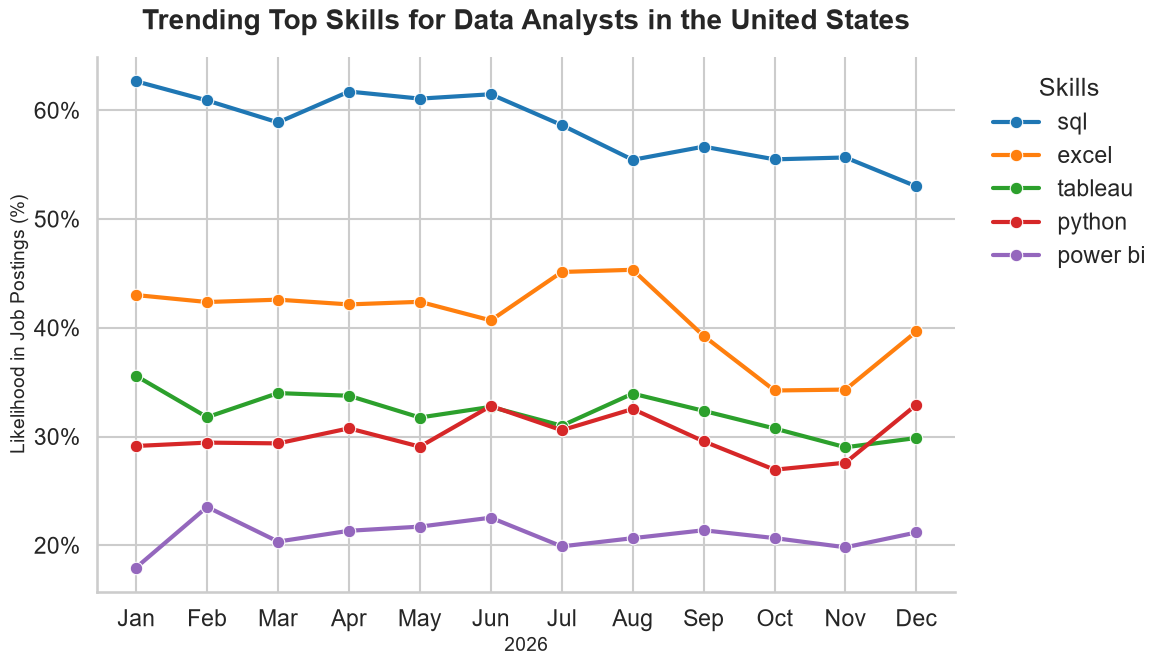

In [43]:
from matplotlib.ticker import PercentFormatter 
df_plot = df_DA_US_percent.iloc[:,:5]
sns.set_theme(style='whitegrid', context='talk')
plt.figure(figsize=(12,7))

sns.lineplot(
    data=df_plot,
    dashes=False,
    palette='tab10',
    linewidth=3,
    marker='o'
)
# Titles and labels
plt.title(
    'Trending Top Skills for Data Analysts in the United States',
    fontsize=20,
    weight='bold',
    pad=20
) 
plt.legend(
    title='Skills',
    bbox_to_anchor=(1.02, 1),
    loc='upper left',
    frameon=False
)
plt.ylabel('Likelihood in Job Postings (%)', fontsize=14)
plt.xlabel('2026', fontsize=14) 

ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

sns.despine()


plt.tight_layout()

plt.show()